# Experimento 4 — Comparativa de Herramientas de Anotación

Compara el rendimiento del modelo histórico (5 técnicas de aumento, exp1_ab) y del modelo de producción (12 técnicas, v2b) en las tres herramientas:

| Herramienta       | Tipo de anotación       |
|:------------------|:------------------------|
| Label Studio      | Automática              |
| CVAT              | Visual manual           |
| ELAN              | Lingüística             |

**Objetivo:** Medir cómo el tipo de anotación afecta la accuracy del mismo modelo. Evidencia directa de la influencia del etiquetado (objetivo 3 de la tesis).

**Prerequisito:** `exp1_ab_pipeline.py`, `modelo/entrenar.py` y `07_extraer_keypoints.py` ejecutados.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import (N_FRAMES, N_KEYPOINTS, DATA_DIR, SPLIT_PATH, CSV_TOP35,
                           KEYPOINTS_DIR)
from utils.preprocessing import normalizar_hombros
from utils.data_io import cargar_herramienta_comparativa

MODELOS_DIR = os.path.join(DATA_DIR, "modelo", "resultados")
EXP_AB_DIR  = os.path.join(DATA_DIR, "experimentos", "exp1_ab", "salidas")
SALIDA_DIR  = os.path.join(DATA_DIR, "experimentos", "exp4_herramientas", "salidas")
os.makedirs(SALIDA_DIR, exist_ok=True)

print(f"Modelos v2: {MODELOS_DIR}")
print(f"Salida:     {SALIDA_DIR}")

C:\Users\dell\AppData\Local\Temp\ipykernel_29676\4043804448.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Modelos v2: C:\Users\dell\Documents\TIC\Codigo_TIC\modelo\resultados
Salida:     C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp4_herramientas\salidas


## Cargar modelos

In [2]:
def cargar_modelo(path, nombre):
    if not os.path.exists(path):
        print(f"  [AVISO] Modelo no encontrado: {path}"); return None
    print(f"  Cargando {nombre}...")
    return tf.keras.models.load_model(path)

model_v2 = cargar_modelo(os.path.join(MODELOS_DIR, 'mejor_modelo_v2.keras'), 'producción (12 aug, v2b)')
model_v1 = cargar_modelo(os.path.join(EXP_AB_DIR,  'modelo_B.h5'),           'histórico (5 aug, exp1_ab)')

if model_v2 is None:
    raise FileNotFoundError("[ERROR] Ejecuta modelo/entrenar.py primero")

  Cargando producción (12 aug, v2b)...


  Cargando histórico (5 aug, exp1_ab)...


## Preparar datos de evaluación

In [3]:
split    = np.load(SPLIT_PATH, allow_pickle=True)
idx_test = split['idx_test'].tolist()

df_top35  = pd.read_csv(CSV_TOP35)
clases    = sorted(df_top35['glosa'].unique())
idx_map   = {c: i for i, c in enumerate(clases)}
n_clases  = len(clases)

# Label Studio (test set fijo)
X_all, y_all = [], []
for _, row in df_top35.iterrows():
    npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
    if not os.path.exists(npy): continue
    kp = np.load(npy)
    if kp.shape != (N_FRAMES, N_KEYPOINTS): continue
    X_all.append(kp); y_all.append(idx_map.get(row['glosa'], -1))
X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
X_ls  = np.array([normalizar_hombros(X_all[i]) for i in idx_test], dtype=np.float32)
y_ls  = y_all[idx_test]

# CVAT y ELAN
X_cvat, y_cvat = cargar_herramienta_comparativa("cvat", idx_map)
X_elan, y_elan = cargar_herramienta_comparativa("elan", idx_map)
if len(X_cvat) == 0: X_cvat = y_cvat = None
if len(X_elan) == 0: X_elan = y_elan = None

print(f"Label Studio: {len(X_ls)} | CVAT: {len(X_cvat) if X_cvat is not None else 0} | ELAN: {len(X_elan) if X_elan is not None else 0}")

Label Studio: 35 | CVAT: 34 | ELAN: 34


## Evaluación por herramienta

In [4]:
def evaluar(model, X, y, nombre_h, nombre_m):
    if model is None or X is None or len(X) == 0: return None
    pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, pred)
    print(f"  [{nombre_m}] {nombre_h:<26} {acc*100:.1f}%  ({len(X)} videos)")
    return acc, pred

herramientas = [
    ('Label Studio (automático)', X_ls,   y_ls),
    ('CVAT (visual manual)',       X_cvat, y_cvat),
    ('ELAN (lingüístico)',         X_elan, y_elan),
]

registros = []
for nombre_h, X, y in herramientas:
    if X is None or len(X) == 0:
        print(f"\n{nombre_h}: sin datos"); continue

    print(f"\n{'='*50}\n{nombre_h}\n{'='*50}")
    res_v2 = evaluar(model_v2, X, y, nombre_h, 'prod')
    res_v1 = evaluar(model_v1, X, y, nombre_h, 'hist') if model_v1 else None

    acc_v2, pred_v2 = res_v2 if res_v2 else (None, None)
    acc_v1          = res_v1[0] if res_v1 else None

    registros.append({
        'herramienta': nombre_h,
        'acc_historico':   round(acc_v1, 4) if acc_v1 else None,
        'acc_produccion':  round(acc_v2, 4) if acc_v2 else None,
        'mejora_pp':       round((acc_v2 - acc_v1)*100, 2) if (acc_v1 and acc_v2) else None,
        'n_videos':        len(X),
    })

# El reporte por clase y las matrices de confusión del modelo de producción
# (por herramienta) ya se generan en modelo/evaluar.py → modelo/resultados/
# (reporte_por_clase.csv, confusion_matrix.png, confusion_matrix_cvat.png,
# confusion_matrix_elan.png). No se duplican aquí: esta notebook se enfoca
# en la comparación histórico vs producción, no en el detalle por clase.


Label Studio (automático)


  [prod] Label Studio (automático)  48.6%  (35 videos)


  [hist] Label Studio (automático)  37.1%  (35 videos)

CVAT (visual manual)
  [prod] CVAT (visual manual)       38.2%  (34 videos)
  [hist] CVAT (visual manual)       26.5%  (34 videos)

ELAN (lingüístico)


  [prod] ELAN (lingüístico)         26.5%  (34 videos)
  [hist] ELAN (lingüístico)         20.6%  (34 videos)


## Detalle por clase del modelo de producción

El reporte por clase y las matrices de confusión (Label Studio, CVAT, ELAN) del
modelo de producción se generan en `modelo/evaluar.py` y viven en
`modelo/resultados/`. Se muestran aquí por referencia, sin recalcularlos.

Label Studio (producción)


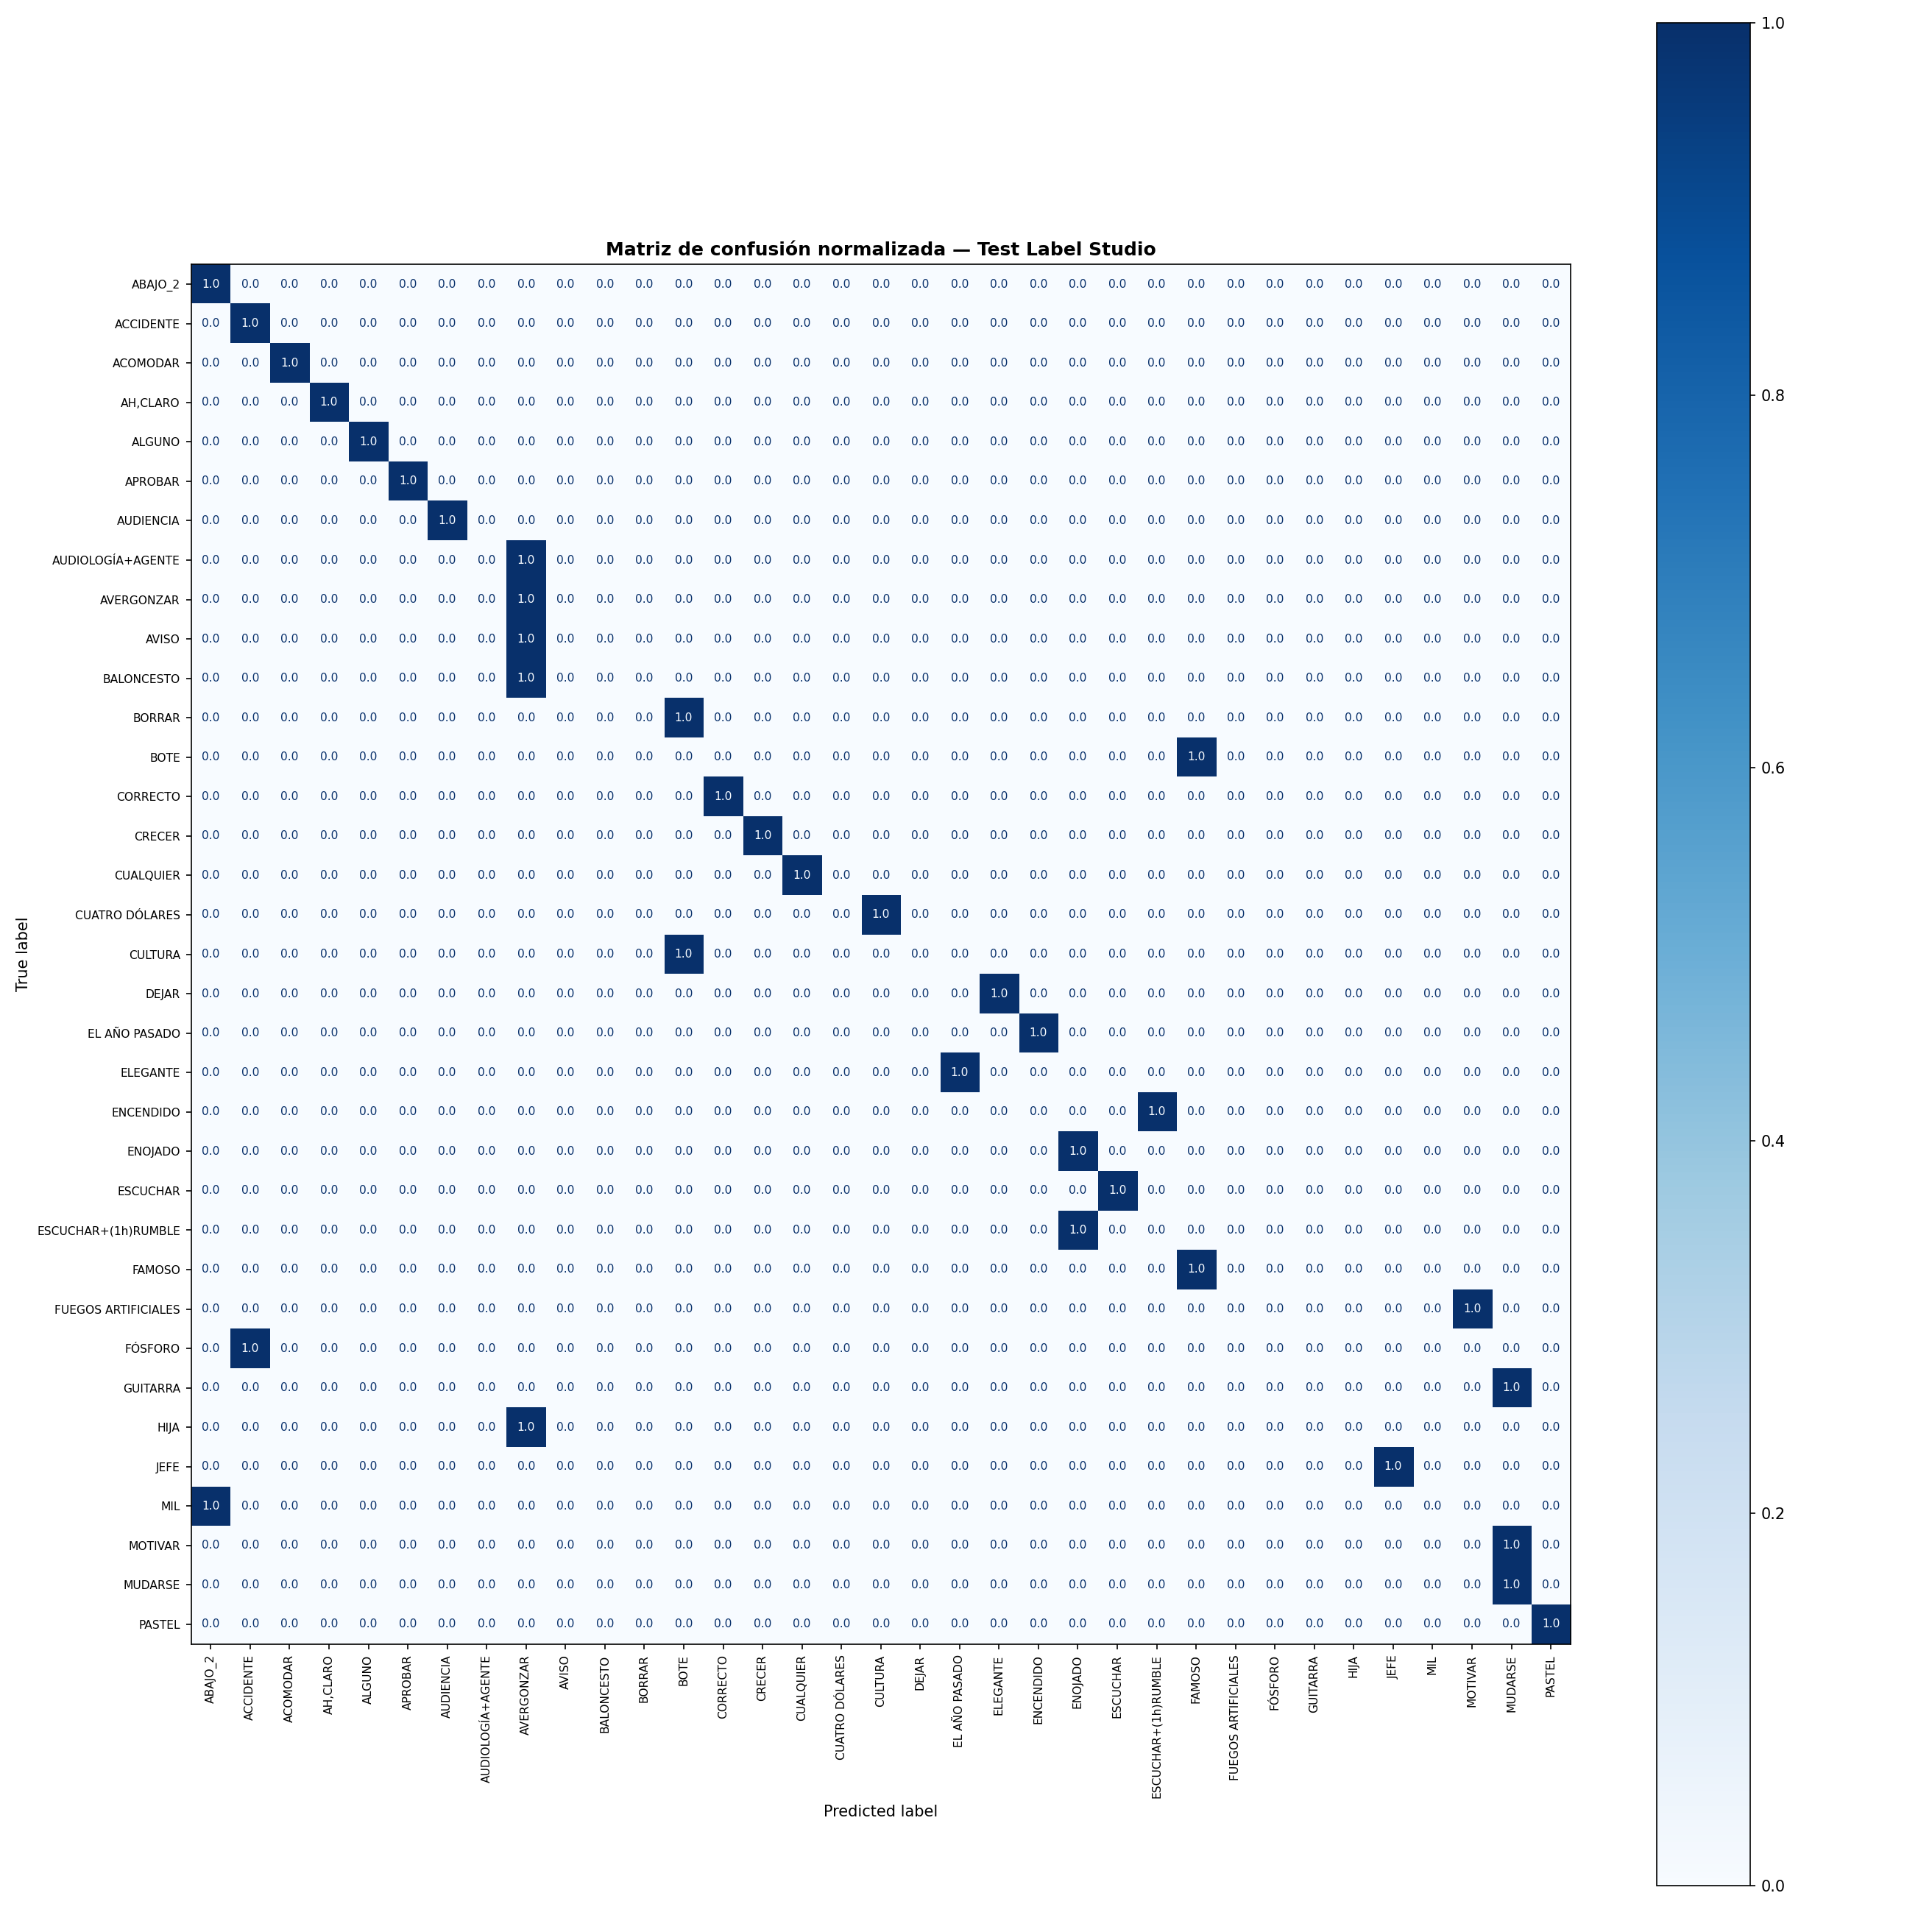

CVAT (producción)


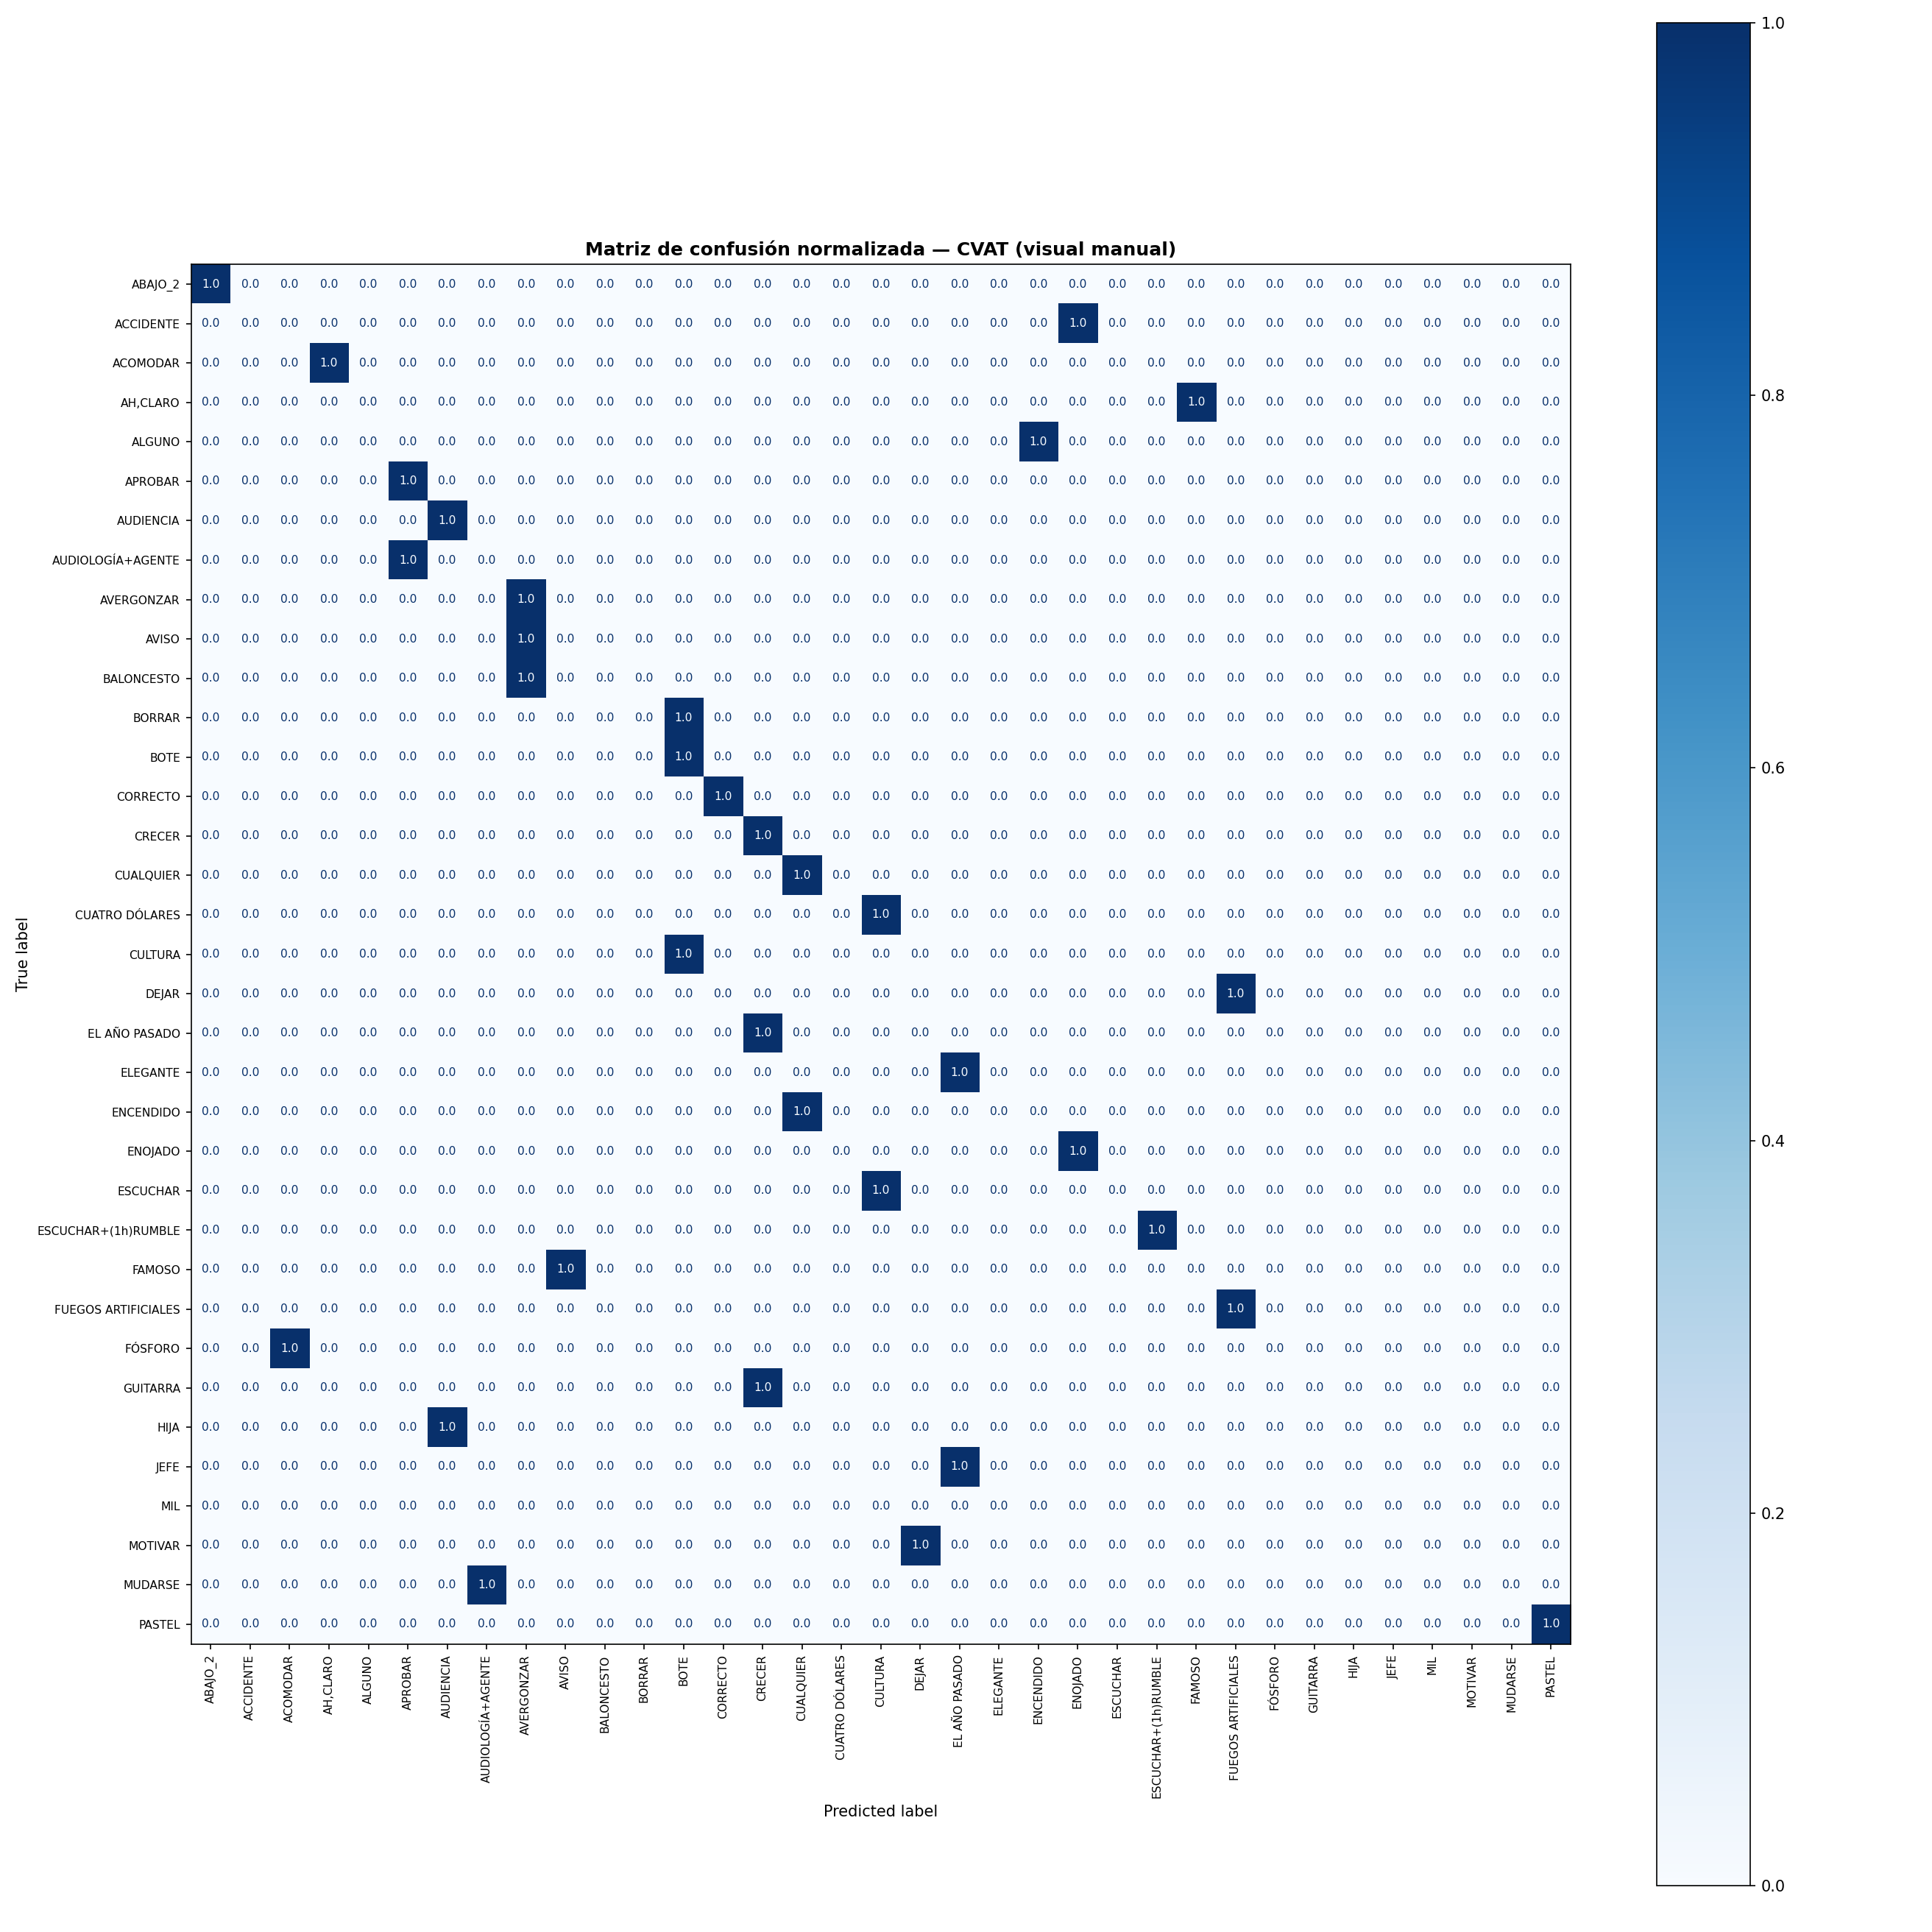

ELAN (producción)


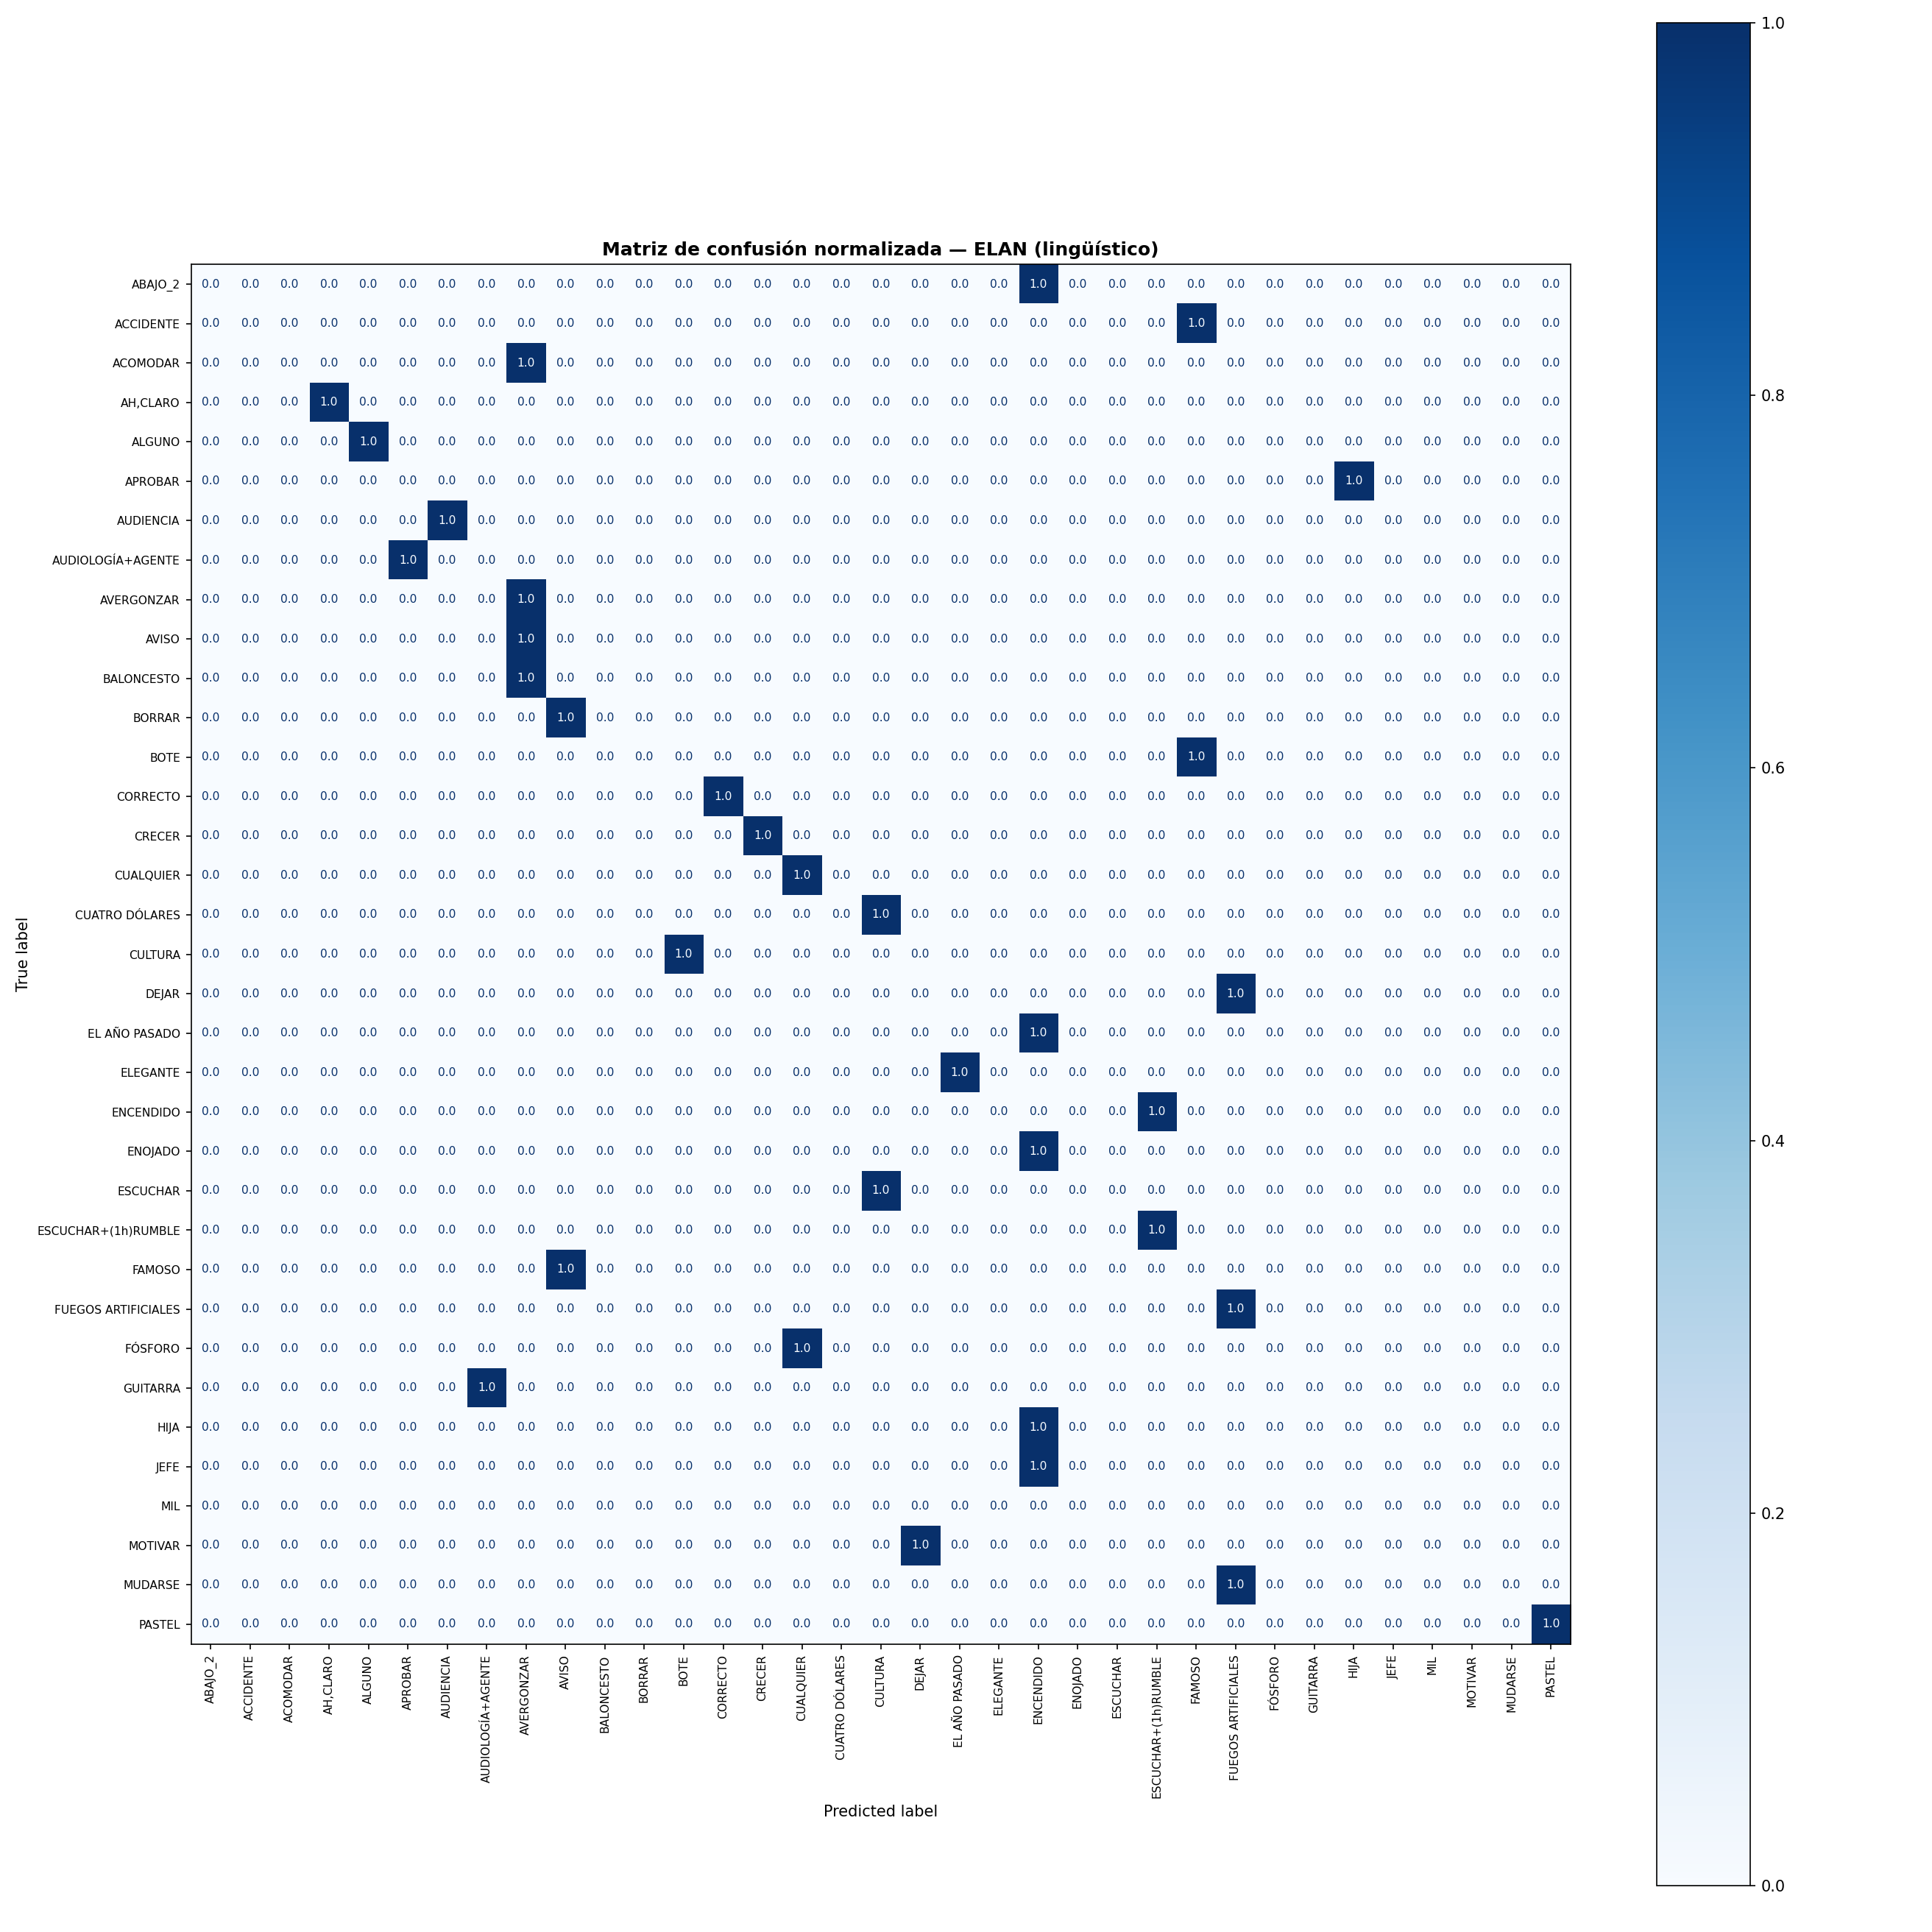

In [5]:
from IPython.display import Image, display

MODELO_RESULTADOS_DIR = os.path.join(DATA_DIR, "modelo", "resultados")

for archivo, titulo in [
    ('confusion_matrix.png',      'Label Studio (producción)'),
    ('confusion_matrix_cvat.png', 'CVAT (producción)'),
    ('confusion_matrix_elan.png', 'ELAN (producción)'),
]:
    ruta = os.path.join(MODELO_RESULTADOS_DIR, archivo)
    if os.path.exists(ruta):
        print(titulo)
        display(Image(filename=ruta))
    else:
        print(f"[AVISO] No encontrado: {ruta}")

## Tabla comparativa final

In [6]:
def pct(v):
    return f"{v*100:.1f} %".replace(".", ",") if v else "N/A"

# Tabla limpia en % impresa en el mismo paso (lista para captura)
print("="*70)
print("  EXACTITUD POR HERRAMIENTA DE ANOTACIÓN (histórico vs producción)")
print("="*70)
print(f"  {'Herramienta':<28}{'Histórico (5)':>14}{'Producción (12)':>18}{'Mejora':>10}")
print("  " + "-"*70)
for r in registros:
    dif = f"{r['mejora_pp']:+.1f} pp".replace(".", ",") if r['mejora_pp'] is not None else ""
    print(f"  {r['herramienta']:<28}{pct(r['acc_historico']):>14}"
          f"{pct(r['acc_produccion']):>18}{dif:>10}")
print("="*70)

# Guardar CSV (valores numéricos) y mostrar DataFrame en % en la notebook
df_res = pd.DataFrame(registros)
df_res.to_csv(os.path.join(SALIDA_DIR, 'comparativa_herramientas_historico_produccion.csv'),
              index=False, encoding='utf-8-sig')
print(f"\nResultados guardados en: {SALIDA_DIR}")

df_pct = df_res.copy()
for c in ['acc_historico', 'acc_produccion']:
    df_pct[c] = df_pct[c].apply(pct)
df_pct

  EXACTITUD POR HERRAMIENTA DE ANOTACIÓN (histórico vs producción)
  Herramienta                  Histórico (5)   Producción (12)    Mejora
  ----------------------------------------------------------------------
  Label Studio (automático)           37,1 %            48,6 %  +11,4 pp
  CVAT (visual manual)                26,5 %            38,2 %  +11,8 pp
  ELAN (lingüístico)                  20,6 %            26,5 %   +5,9 pp

Resultados guardados en: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp4_herramientas\salidas


,herramienta,acc_historico,acc_produccion,mejora_pp,n_videos
0,Label Studio (automático),"37,1 %","48,6 %",11.43,35
1,CVAT (visual manual),"26,5 %","38,2 %",11.76,34
2,ELAN (lingüístico),"20,6 %","26,5 %",5.88,34


## Visualización

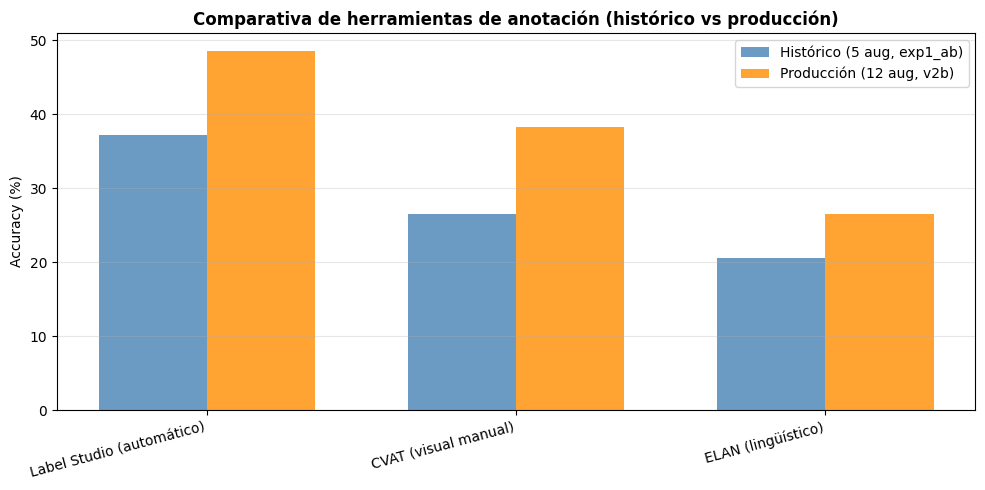

In [7]:
import matplotlib.pyplot as plt

df_plot = df_res.dropna(subset=['acc_produccion'])

x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
if 'acc_historico' in df_plot.columns and df_plot['acc_historico'].notna().any():
    ax.bar([i - width/2 for i in x], df_plot['acc_historico']*100, width,
           label='Histórico (5 aug, exp1_ab)', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], df_plot['acc_produccion']*100, width,
       label='Producción (12 aug, v2b)', color='darkorange', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['herramienta'], rotation=15, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparativa de herramientas de anotación (histórico vs producción)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'comparativa_herramientas.png'), dpi=150)
plt.show()